In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
Flu_weather = pd.read_csv("NY_Flu_Weather_Final_Weekly.csv")

Flu_weather.head()


,County,Year,Month,Season,Region,Week,Week Ending Date,Disease,Infected,Avg household size,...,Latitude,Longitude,Prob_infected,County_Density,Ending Date,avg_temp_prior_week,avg_humidity_prior_week,avg_dew_point_prior_week,avg_precip_prior_week,avg_wind_speed_prior_week
0,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_A,4,2.3,...,42.601,-73.977,0.000013,582.162575,2009-10-10,52.136235,75.422893,44.082307,0.082677,11.513748
1,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_B,0,2.3,...,42.601,-73.977,0.000000,582.162575,2009-10-10,52.136235,75.422893,44.082307,0.082677,11.513748
2,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_UNSPECIFIED,0,2.3,...,42.601,-73.977,0.000000,582.162575,2009-10-10,52.136235,75.422893,44.082307,0.082677,11.513748
3,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,41,10/17/2009,INFLUENZA_A,11,2.3,...,42.601,-73.977,0.000036,582.162575,2009-10-17,39.730165,68.109046,29.425700,0.042745,7.608064
4,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,41,10/17/2009,INFLUENZA_B,0,2.3,...,42.601,-73.977,0.000000,582.162575,2009-10-17,39.730165,68.109046,29.425700,0.042745,7.608064


In [37]:
# See which counties/years have the most '60 degree' weeks
outlier_check = Flu_weather[Flu_weather['avg_temp_prior_week'] == 60]
print(outlier_check['County'].value_counts())
print(outlier_check['Year'].value_counts())

# This catches 59.9, 60.1, etc.
outlier_check = Flu_weather[Flu_weather['avg_temp_prior_week'].between(59.5, 60.5)]
print(outlier_check['County'].value_counts().head())

# Check for 'dead' counties
weather_variance = Flu_weather.groupby('County')['avg_temp_prior_week'].nunique()
print(weather_variance[weather_variance == 1])

Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
County
NASSAU              36
HERKIMER            24
GENESEE             21
KINGS (BROOKLYN)    21
SUFFOLK             21
Name: count, dtype: int64
Series([], Name: avg_temp_prior_week, dtype: int64)


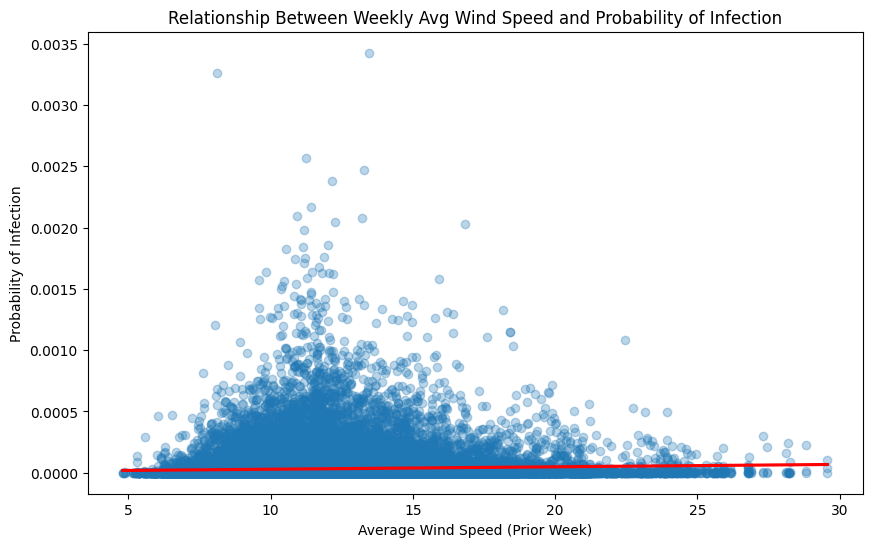

In [39]:
plt.figure(figsize=(10, 6))
sns.regplot(data=Flu_weather, x='avg_wind_speed_prior_week', y='Prob_infected', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Relationship Between Weekly Avg Wind Speed and Probability of Infection')
plt.xlabel('Average Wind Speed (Prior Week)')
plt.ylabel('Probability of Infection')
plt.show()


In [17]:
# Check which counties are contributing to the 50-degree pillar
# We look for values very close to 50 (e.g., 49.9 to 50.1)
pillar_50 = Flu_weather[Flu_weather['avg_temp_prior_week'].between(49.9, 50.1)]

print("--- Counties with most 50-degree readings ---")
print(pillar_50['County'].value_counts().head(10))

# Check if these are 'dead' counties (constant 50) or just occasional
dead_50_counties = Flu_weather.groupby('County')['avg_temp_prior_week'].nunique()
print("\nCounties with almost zero variance (Potential API ghosts):")
print(dead_50_counties[dead_50_counties < 5]) # Adjust threshold as needed

--- Counties with most 50-degree readings ---
County
BRONX          6
BROOME         6
CATTARAUGUS    6
CHAUTAUQUA     6
CAYUGA         3
CHEMUNG        3
CLINTON        3
Name: count, dtype: int64

Counties with almost zero variance (Potential API ghosts):
County
COLUMBIA                    1
CORTLAND                    1
DELAWARE                    1
DUTCHESS                    1
ERIE                        1
ESSEX                       1
FRANKLIN                    1
FULTON                      1
GENESEE                     1
GREENE                      1
HAMILTON                    1
HERKIMER                    1
JEFFERSON                   1
KINGS (BROOKLYN)            1
LEWIS                       1
LIVINGSTON                  1
MADISON                     1
MONROE                      1
MONTGOMERY                  1
NASSAU                      1
NEW YORK (MANHATTAN)        1
NIAGARA                     1
ONEIDA                      1
ONONDAGA                    1
ONTARIO        

New Feature 'RSI_Lag_1wk' created successfully.
       Prob_infected     RSI_Score
count   57846.000000  57846.000000
mean        0.000032      1.739142
std         0.000112      0.287678
min         0.000000      0.240311
25%         0.000000      1.548602
50%         0.000000      1.757388
75%         0.000010      1.927048
max         0.003426      2.632487


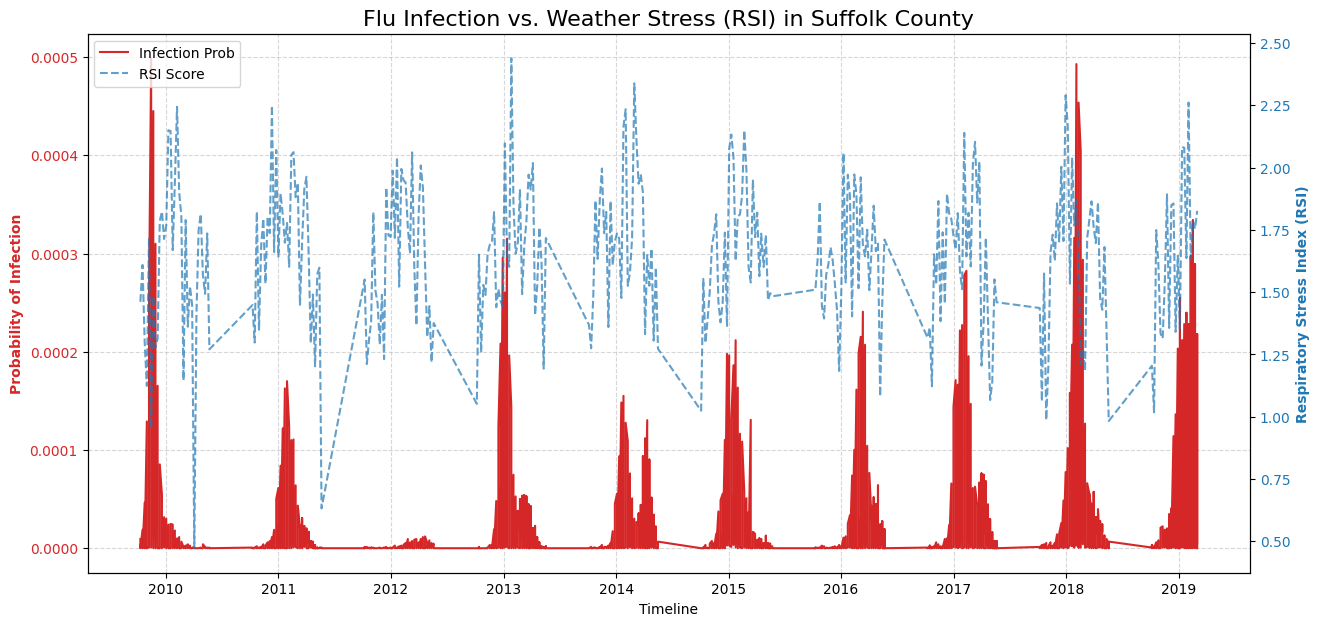

In [50]:
# Create the Respiratory Stress Index (RSI)
# We normalize the features so they are on the same 0-1 scale, 
# then invert them because LOWER temp/humidity/precip = HIGHER stress.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_normalize = ['avg_temp_prior_week', 'avg_humidity_prior_week', 'avg_precip_prior_week']

# 1. Scale the features
scaled_features = scaler.fit_transform(Flu_weather[cols_to_normalize])

# 2. Invert and combine
# Stress = (1 - Normalized Temp) + (1 - Normalized Humidity) + (1 - Normalized Precip)
Flu_weather['RSI_Score'] = (1 - scaled_features[:, 0]) + \
                           (1 - scaled_features[:, 1]) + \
                           (1 - scaled_features[:, 2])

# 3. Create a "Lagged RSI" (Stress from 1 week ago predicts infections TODAY)
Flu_weather = Flu_weather.sort_values(['County', 'Ending Date'])
Flu_weather['RSI_Lag_1wk'] = Flu_weather.groupby('County')['RSI_Score'].shift(1)

print("New Feature 'RSI_Lag_1wk' created successfully.")


import matplotlib.pyplot as plt
import seaborn as sns

# Run this right before the plot code
print(Flu_weather[['Prob_infected', 'RSI_Score']].describe())

import matplotlib.pyplot as plt

# 1. Filter and FORCE data types
county_name = 'Suffolk'
# case-insensitive filter just to be safe
county_df = Flu_weather[Flu_weather['County'].str.contains(county_name, case=False, na=False)].copy()

# 2. CRITICAL: Convert Ending Date to datetime and sort
county_df['Ending Date'] = pd.to_datetime(county_df['Ending Date'])
county_df = county_df.sort_values('Ending Date')

# 3. Drop rows where either plotted value is missing (Matplotlib hates NaNs in lines)
plot_df = county_df.dropna(subset=['Prob_infected', 'RSI_Score'])

# --- START PLOT ---
fig, ax1 = plt.subplots(figsize=(15, 7))

# Infection Prob (Left Axis)
color_inf = 'tab:red'
ax1.set_xlabel('Timeline')
ax1.set_ylabel('Probability of Infection', color=color_inf, fontweight='bold')
ax1.plot(plot_df['Ending Date'], plot_df['Prob_infected'], color=color_inf, label='Infection Prob', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color_inf)

# RSI Score (Right Axis)
ax2 = ax1.twinx()
color_rsi = 'tab:blue'
ax2.set_ylabel('Respiratory Stress Index (RSI)', color=color_rsi, fontweight='bold')
ax2.plot(plot_df['Ending Date'], plot_df['RSI_Score'], color=color_rsi, label='RSI Score', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color_rsi)

plt.title(f'Flu Infection vs. Weather Stress (RSI) in {county_name} County', fontsize=16)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# Combined Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.savefig('flu_rsi_comparison.png')

plt.show()


In [40]:
# List the columns you want to check
target_cols = ['avg_precip_prior_week', 'avg_wind_speed_prior_week']

# Count non-null values for each
val_counts = Flu_weather[target_cols].count()

print("--- Valid Value Counts ---")
print(val_counts)

# Optional: Check if any are exactly 0 (which might happen with precip)
zero_counts = (Flu_weather[target_cols] == 0).sum()
print("\n--- Zero Value Counts ---")
print(zero_counts)

--- Valid Value Counts ---
avg_precip_prior_week        57846
avg_wind_speed_prior_week    57846
dtype: int64

--- Zero Value Counts ---
avg_precip_prior_week        696
avg_wind_speed_prior_week      0
dtype: int64
